# Análisis de Datos con NumPy, Pandas y Matplotlib: Portafolio Final

Estas preguntas son clave para entender qué se quiere lograr con el análisis de datos:

## **1. Objetivo del Análisis**

* **¿Cuál es el propósito principal del análisis?**
    * El objetivo principal del análisis es entender los patrones de compra, identificar los productos más vendidos y los clientes más valiosos, y detectar posibles tendencias en las ventas. Esto podría ayudar a optimizar inventarios, mejorar estrategias de marketing, y aumentar la satisfacción del cliente.

* **¿Qué preguntas específicas quieres responder?**
    * ¿Cuáles son los productos más vendidos?
    * ¿Quiénes son los clientes más valiosos?
    * ¿Hay patrones estacionales o tendencias en las ventas?
    * ¿Qué factores contribuyen a las compras repetidas?

# **2. Contexto del Negocio**

* **¿Qué tipo de negocio está relacionado con estos datos?**
    * El dataset parece estar relacionado con un comercio minorista en línea que vende una variedad de productos. Esto se deduce de la estructura típica de los datos de ventas en línea, que incluyen códigos de productos, descripciones, precios y transacciones con clientes.

* **¿Cuáles son los objetivos generales de la empresa?**
    * Aumentar las ventas, mejorar la retención de clientes, optimizar la gestión de inventarios y mejorar la eficiencia en la operación de la tienda en línea.

* **¿Quiénes son los principales interesados (stakeholders)?**
    * Directores de ventas, gerentes de marketing, equipos de operaciones y de gestión de inventario, y analistas financieros que se beneficiarían de una mejor comprensión de los datos de ventas y patrones de clientes.

# **3. Alcance del Análisis**

* **¿Qué aspectos están dentro y fuera del alcance del análisis?**
    * Dentro del alcance: análisis de ventas, identificación de productos y clientes clave, patrones estacionales, y tendencias de ventas.
    * Fuera del alcance: análisis detallado de la logística de entrega, estudio de competencia directa, o análisis de satisfacción del cliente basado en feedback no presente en el dataset.

* **¿Qué limitaciones deben tenerse en cuenta?**
    * Limitaciones pueden incluir la calidad de los datos (posibles valores faltantes o erróneos), el periodo temporal cubierto por los datos, y la falta de datos cualitativos sobre la experiencia del cliente.

## **4. Resultados Esperados**

* **¿Qué tipo de resultados se espera del análisis?**
    * Informes detallados que identifiquen los productos más vendidos y los clientes más valiosos.
    * Visualizaciones que muestren tendencias y patrones en las ventas.
    * Posibles modelos predictivos para proyectar ventas futuras o recomendar estrategias de marketing.

* **¿Cómo se utilizarán estos resultados?**
    * Los resultados se utilizarán para tomar decisiones estratégicas sobre inventarios, campañas de marketing, y para mejorar la experiencia del cliente y aumentar las ventas.

--------------

In [32]:
import pandas as pd

# Carga el dataset
data = pd.read_csv('./online_retail.csv')

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [34]:
data.head()  # Muestra las primeras filas del dataset

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [35]:
data.describe()  # Muestra un resumen estadístico del dataset

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [36]:
data.isnull().sum()  # Verifica si hay valores nulos en el dataset

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [37]:
data.duplicated().sum()  # Verifica si hay filas duplicadas en el dataset

np.int64(5268)

In [38]:
unique_values = {col: data[col].unique() for col in data.columns}

for col, values in unique_values.items():
    print(f"Columna: {col}")
    print(f"Número de valores únicos: {len(values)}")
    print(f"Valores únicos: {values[:10]}")
    print("-" * 50)

Columna: InvoiceNo
Número de valores únicos: 25900
Valores únicos: ['536365' '536366' '536367' '536368' '536369' '536370' '536371' '536372'
 '536373' '536374']
--------------------------------------------------
Columna: StockCode
Número de valores únicos: 4070
Valores únicos: ['85123A' '71053' '84406B' '84029G' '84029E' '22752' '21730' '22633'
 '22632' '84879']
--------------------------------------------------
Columna: Description
Número de valores únicos: 4224
Valores únicos: ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'ASSORTED COLOUR BIRD ORNAMENT']
--------------------------------------------------
Columna: Quantity
Número de valores únicos: 722
Valores únicos: [ 6  8  2 32  3  4 24 12 48 18]
-------------------------------------------------

In [39]:
data_cleaned = data.drop_duplicates()
data_cleaned = data_cleaned.dropna(subset=['CustomerID'])

In [40]:
data_cleaned.isnull().sum()  # Verifica si hay valores nulos después de limpiar

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [41]:
data_cleaned.duplicated().sum()  # Verifica si hay filas duplicadas después de limpiar

np.int64(0)

# Transformaciones de Datos para Análisis en Pandas

## **¿Cómo se calculan las columnas adicionales en un set de datos?**
Al trabajar con datos, es fundamental entender cómo podemos derivar nueva información para maximizar el valor de nuestro análisis. Este enfoque es crucial para la etapa de transformación de datos, donde convertimos las columnas existentes en nuevas estructuras que faciliten un análisis más profundo. Por ejemplo, desde columnas como `cantidad` y `precio unitario`, podemos crear una columna adicional llamada `monto total`, simplemente multiplicando dichas columnas. Este enfoque también aplica a otros tipos de datos, como fechas, que pueden ser transformadas a formatos de series temporales para facilitar su uso.

## **Creando nuevas columnas a partir de datos existentes**

**1. Creación de la columna `monto total`:** La columna `monto total` se crea multiplicando `cantidad` por `precio unitario`. Esto se hace de la siguiente manera en código Python usando Pandas:

```Python
data['monto total'] = data['cantidad'] * data['precio unitario']
```

**2. Transformación de fechas:** Al trabajar con fechas, es útil convertirlas a un formato datetime para facilidades posteriores de análisis. Con Pandas, puedes hacerlo así:

```Python
data['invoice date'] = pd.to_datetime(data['invoice date'])
```

Esto permite entonces extraer más información específica, como el año, el mes, o incluso la hora, creando columnas adicionales:

```Python
data['año'] = data['invoice date'].dt.year
data['mes'] = data['invoice date'].dt.month
```

## **¿Qué ventajas tiene desglosar la información temporal?**

Desglosar información temporal provee una perspectiva detallada de los datos. La conversión de fechas a tipos de datos datetime nos permite segmentar datos en función del tiempo, lo cual es valioso para identificar tendencias a lo largo de periodos específicos. Esta segmentación es vital para el análisis financiero, especialmente al revisar ventas anuales, semestrales o trimestrales.

## **Implementación del desglose temporal**

Para crear un desglose semestral, primero asignamos cada mes a un semestre usando una función lambda:

```Python
data['semestre'] = data['mes'].apply(lambda x: 1 if x <= 6 else 2)
```

Posteriormente, puedes agrupar los datos por año y semestre para obtener insights:

```Python
ventas_por_semestre = data.groupby(['año', 'semestre'])['monto total'].sum().reset_index()
```

Esta agrupación permite observar las ventas repartidas en segmentos temporales específicos, facilitando un análisis comparativo entre distintos periodos.

## **¿Cómo agrupar y sumar datos para el análisis de ventas?**

Al reunir y sumar información de ventas por distintos segmentos de tiempo, podemos tomar decisiones informadas sobre patrones de consumo y rendimiento de las ventas a través de diferentes periodos.

## **Análisis de ventas anuales y semestrales**

Al desglosar ventas anuales y semestrales, primero agrupamos los datos utilizando la funcionalidad de `groupby` en Pandas. Luego sumamos las ventas para cada grupo:

**Para ventas anuales:**

```Python
ventas_por_año = data.groupby('año')['monto total'].sum().reset_index()
```

**Para ventas semestrales:**

```Python
ventas_por_semestre = data.groupby(['año', 'semestre'])['monto total'].sum().reset_index()
```

Esto te proporciona un conjunto de datos consolidado que refleja las métricas clave, permitiendo hacer evaluaciones y ajustes estratégicos basados en períodos temporales.

## **¿Por qué es importante generar insights adicionales a partir de datos existentes?**

Ampliar el análisis de datos mediante la extracción de insights adicionales fomenta un entendimiento más profundo y aplicable de los datos. Esto no solo potencia la toma de decisiones empresariales, sino que también enriquece las estrategias a implementar.

Al derivar datos temporales y categóricos, visualizamos tendencias que no son evidentes a simple vista. Además, determinar ventas trimestrales o mensuales permite identificar patrones cíclicos, picos de demanda, o periodos de recesión, lanzando luz sobre cómo optimizar operaciones y estrategias de marketing.

En este enfoque, se invita al lector a aplicar procesos similares y seguir explorando hasta crear insights significativos que aporten valor a su contexto particular.

In [42]:
data_cleaned.head() # Muestra las primeras filas del dataset limpio

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [43]:
data_cleaned.info()  # Verifica la información del dataset limpio

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [44]:
data_cleaned['TotalAmount'] = data_cleaned['Quantity'] * data_cleaned['UnitPrice']
data_cleaned.head()  # Muestra las primeras filas con la nueva columna 'TotalAmount'

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [45]:
data_cleaned['InvoiceDate'] = pd.to_datetime(data_cleaned['InvoiceDate'])
data_cleaned.head()  # Muestra las primeras filas con la columna 'InvoiceDate' convertida a datetime

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [46]:
data_cleaned.info()  # Verifica la información del dataset limpio

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
 8   TotalAmount  401604 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.6+ MB


In [47]:
data_cleaned['Year'] = data_cleaned['InvoiceDate'].dt.year
data_cleaned['Month'] = data_cleaned['InvoiceDate'].dt.month
data_cleaned.head()  # Muestra las primeras filas con las nuevas columnas 'Year' y 'Month'

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12


In [48]:
sales_by_year = data_cleaned.groupby('Year')['TotalAmount'].sum()
sales_by_year

Year
2010     552372.860
2011    7726146.564
Name: TotalAmount, dtype: float64

In [49]:
data_cleaned['Semester'] = data_cleaned['Month'].apply(lambda x: 1 if x <= 6 else 2)

In [50]:
sales_by_semester = data_cleaned.groupby(['Year', 'Semester'])['TotalAmount'].sum()
sales_by_semester

Year  Semester
2010  2            552372.860
2011  1           3166939.041
      2           4559207.523
Name: TotalAmount, dtype: float64

In [51]:
data_cleaned['Trimester'] = data_cleaned['Month'].apply(lambda x: (x - 1) // 3 + 1)
sales_by_trimester = data_cleaned.groupby(['Year', 'Trimester'])['TotalAmount'].sum()
sales_by_trimester

Year  Trimester
2010  4             552372.860
2011  1            1487842.180
      2            1679096.861
      3            2117546.643
      4            2441660.880
Name: TotalAmount, dtype: float64

In [52]:
sales_by_month = data_cleaned.groupby(['Year', 'Month'])['TotalAmount'].sum()
sales_by_month

Year  Month
2010  12        552372.860
2011  1         473731.900
      2         435534.070
      3         578576.210
      4         425222.671
      5         647011.670
      6         606862.520
      7         573112.321
      8         615078.090
      9         929356.232
      10        973306.380
      11       1126815.070
      12        341539.430
Name: TotalAmount, dtype: float64

-------------

# Visualización de Datos con Matplotlib: Gráficos de Barras y Pastel

## **¿Cómo visualizar los datos de nuestras transacciones?**

Visualizar datos no es solo una cuestión estética; es un pilar fundamental para entender y comunicar nuestras historias de datos de manera efectiva. En este contexto, utilizamos `Matplotlib`, una de las librerías más versátiles en Python, para realizar gráficos que representan nuestras transacciones. Nuestro enfoque principal es identificar las devoluciones y las transacciones efectivas en nuestra base de datos.

## **¿Cómo contamos las devoluciones y las transacciones sin devolución?**

Comenzamos clasificando nuestras transacciones en aquellas con devoluciones y aquellas sin ellas. Utilizamos nuestro `DataFrame` para filtrar:

```Python
# Transacciones con devoluciones
total_devoluciones = df[df['cantidad'] < 0]
print(total_devoluciones.shape[0])  # Total de devoluciones: 8,872

# Transacciones sin devoluciones
sin_devoluciones = df[df['cantidad'] >= 0]
print(sin_devoluciones.shape[0])
```

Esto nos permite tener una visión clara sobre cuántas transacciones implicaron devoluciones versus cuántas no lo hicieron.

## ¿Cómo podemos crear un gráfico de pastel para visualizar devoluciones?

La visualización con gráficos de pastel nos ayuda a interpretar la proporción de transacciones con devoluciones frente a las que no. Así es como creamos este tipo de visualización:

**1. Importar Matplotlib** y preparar los datos:

```Python
import matplotlib.pyplot as plt

labels = ['Devoluciones', 'No devoluciones']
sizes = [total_devoluciones.shape[0], sin_devoluciones.shape[0]]
colors = ['coral', 'lightgreen']
Configurar y mostrar el gráfico de pastel:
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, startangle=140, autopct='%1.1f%%')
plt.title('Porcentaje de Transacciones con y sin Devolución')
plt.show()
```

Este gráfico ilustra visualmente la relación entre devoluciones y transacciones exitosas, permitiéndonos identificar rápidamente tendencias o anomalías.

**2. Configurar y mostrar el gráfico de pastel:**

```Python
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, startangle=140, autopct='%1.1f%%')
plt.title('Porcentaje de Transacciones con y sin Devolución')
plt.show()
```

Este gráfico ilustra visualmente la relación entre devoluciones y transacciones exitosas, permitiéndonos identificar rápidamente tendencias o anomalías.

## **¿Cómo evaluar las ventas por mes y año?**

Analizar las ventas por intervalos de tiempo puede ofrecer perspectivas únicas y detalladas sobre el comportamiento de compra. Al usar gráficos de barras, podemos deducir claramente cuál ha sido el comportamiento de las ventas a lo largo del tiempo.

## **¿Cómo creamos un gráfico de barras para las ventas?**

El gráfico de barras es perfecto para visualizar cambios cuantitativos. Sigamos los pasos para implementarlo:

**1. Agrupar los datos por año y mes:**

```Python
monthly_sales = df.groupby(['año', 'mes'])['total_amount'].sum()
```

**2. Diseñar el gráfico:**

```Python
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='bar')
plt.title('Distribución de Ventas por Mes y Año')
plt.xlabel('Año, Mes')
plt.ylabel('Ventas Totales')
plt.show()
```

Esta estrategia nos permite identificar picos en las ventas y entender mejor el impacto estacional y mensual sobre el rendimiento de nuestras ventas.

## **¿Cuáles son los 10 productos más vendidos?**

Finalmente, es esencial conocer cuáles productos se destacan en nuestro portafolio. Al crear un gráfico de barras horizontal del top de productos, conseguimos esta importante información.

## **¿Cómo agrupamos y visualizamos los productos más vendidos?**

**1. Agrupar por `stock code` y ordenar:**

```Python
top_products = df.groupby('stock_code')['cantidad'].sum().sort_values(ascending=False).head(10)
```

**2. Dibujar el gráfico:**

```Python
plt.figure(figsize=(12, 8))
top_products.plot(kind='barh', color='skyblue')
plt.title('Top 10 Productos Más Vendidos')
plt.xlabel('Cantidad Vendida')
plt.ylabel('Producto')
plt.gca().invert_yaxis()  # Para que el producto más vendido aparezca arriba
plt.show()
```

Este gráfico nos dota de valiosos insights sobre qué productos impulsan más ventas y permiten un mejor posicionamiento estratégico.

En conclusión, el dominio de herramientas y técnicas de visualización de datos como las vistas aquí son esenciales para cualquier profesional en ciencia de datos. No solo enriquecen nuestras presentaciones, sino que también nos proporcionan la información clave para tomar decisiones informadas. Recuerda seguir practicando con tus propios sets de datos para fortalecer tu conocimiento.

In [53]:
data_cleaned.head()  # Muestra las primeras filas del dataset limpio

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Semester,Trimester
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2,4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2,4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,4


In [54]:
total_returns = data_cleaned[data_cleaned['Quantity'] < 0].shape[0]
total_returns

8872

In [55]:
total_non_returns = data_cleaned[data_cleaned['Quantity'] >= 0].shape[0]
total_non_returns

392732

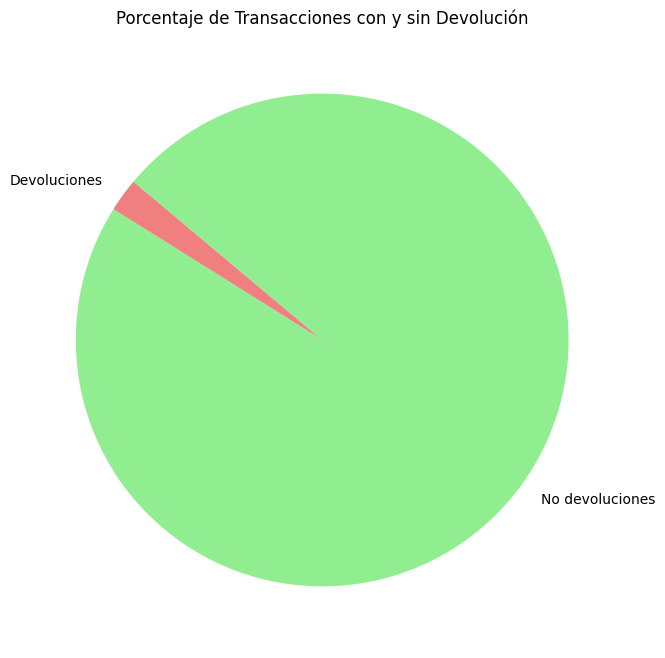

In [56]:
import matplotlib.pyplot as plt

labels = ['Devoluciones', 'No devoluciones']
sizes = [total_returns, total_non_returns]
colors = ['lightcoral', 'lightgreen']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, startangle=140)

plt.title('Porcentaje de Transacciones con y sin Devolución')

plt.show()

In [57]:
# Crear una columna categorica basada en el monto total de la transaccion
def categorize_total_amount(amount):
    if amount < 20:
        return 'Low'
    elif 20 <= amount < 100:
        return 'Medium'
    else:
        return 'High'

data_cleaned['AmountCategory'] = data_cleaned['TotalAmount'].apply(categorize_total_amount)
data_cleaned.head()  # Muestra las primeras filas con la nueva columna 'AmountCategory'

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Semester,Trimester,AmountCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2,4,Low
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,4,Medium
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2,4,Medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,4,Medium
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2,4,Medium


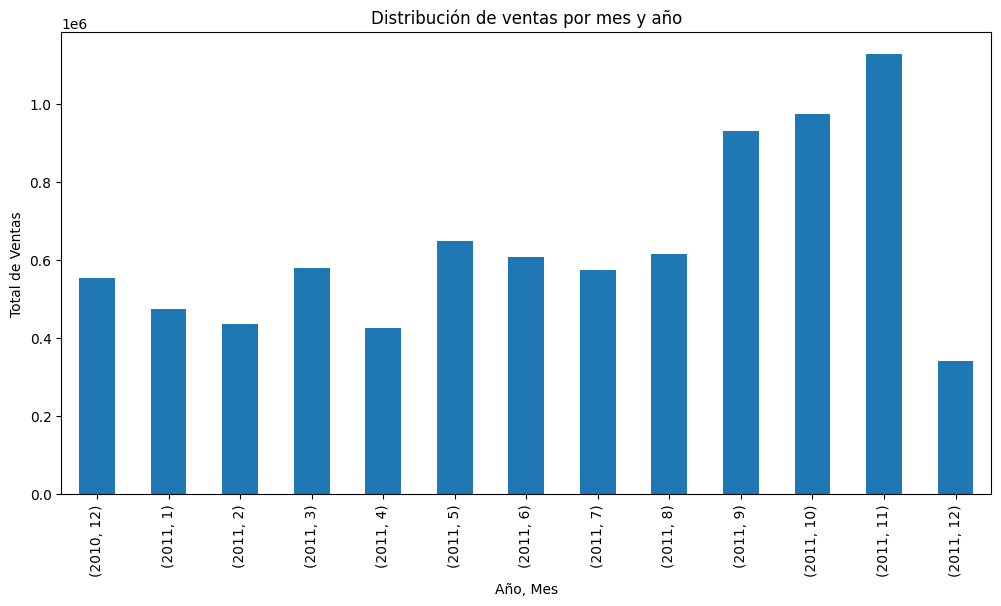

In [58]:
plt.figure(figsize=(12, 6))
data_cleaned.groupby(['Year', 'Month'])['TotalAmount'].sum().plot(kind='bar')
plt.title('Distribución de ventas por mes y año')
plt.xlabel('Año, Mes')
plt.ylabel('Total de Ventas')
plt.show()

In [59]:
top_products = data_cleaned.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products = top_products.reset_index()
top_products = pd.merge(top_products, data_cleaned[['StockCode', 'Description']].drop_duplicates(), on='StockCode', how='left')

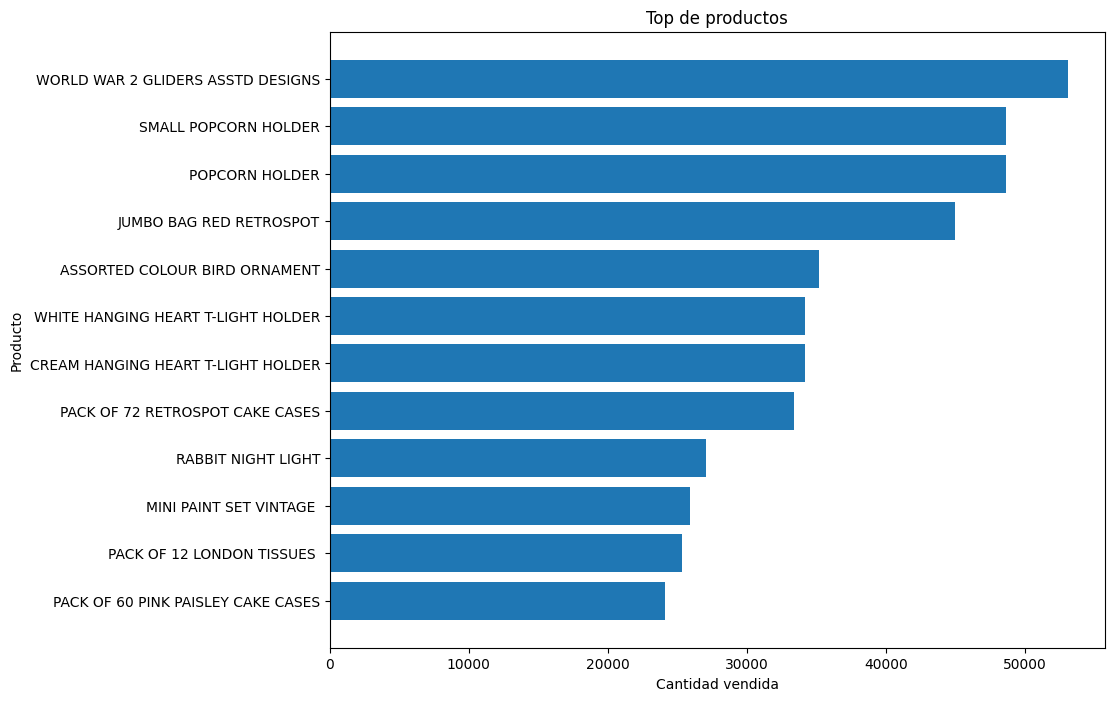

In [61]:
plt.figure(figsize=(10, 8))
plt.barh(top_products['Description'], top_products['Quantity'])
plt.title('Top de productos')
plt.xlabel('Cantidad vendida')
plt.ylabel('Producto')
plt.gca().invert_yaxis()  # Invierte el eje y para que el producto más vendido aparezca arriba

plt.show()